# Code Development for the Python Analysis of the Global Rights Data

## Loading libraries

In [1]:
import diversedata as dd
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer # no quality assurance
from sklearn.impute import IterativeImputer
from IPython.display import Markdown

## 1. Data Cleaning and Processing

In [2]:
global_rights = dd.load_data("globalrights")

# Select and clean variables (excluding marriage from transformation)
cleaned_rights = global_rights[
    [
        "country",
        "year",
        "gdp-per-capita",
        "education-spending-gdp",
        "same-sex-marriage",
        "lgbtq-censorship",
        "employment-discrimination",
        "gender-affirming-care",
        "legal-gender",
    ]
]

# Rename columns
cleaned_rights.columns = [
    "country",
    "year",
    "gdp_per_capita",
    "edu_spend",
    "same_sex_marriage",
    "lgbtq_censorship",
    "employment",
    "affirming_care",
    "legal_gender",
]

## 2. Aggregation Plots

In [3]:
missing_prop = (
    cleaned_rights.isnull()
      .mean()
      .reset_index()
      .rename(columns={"index": "variable", 0: "missing_prop"})
)

alt.Chart(missing_prop).mark_bar().encode(
    x=alt.X("variable").sort("-y"),
    y=alt.Y("missing_prop").axis(alt.Axis(format="%")),
    tooltip=["variable", "missing_prop"]
).properties(
    title="Missing Data per Variable",
    width=400,
    height=300
)

alt.Chart(...)

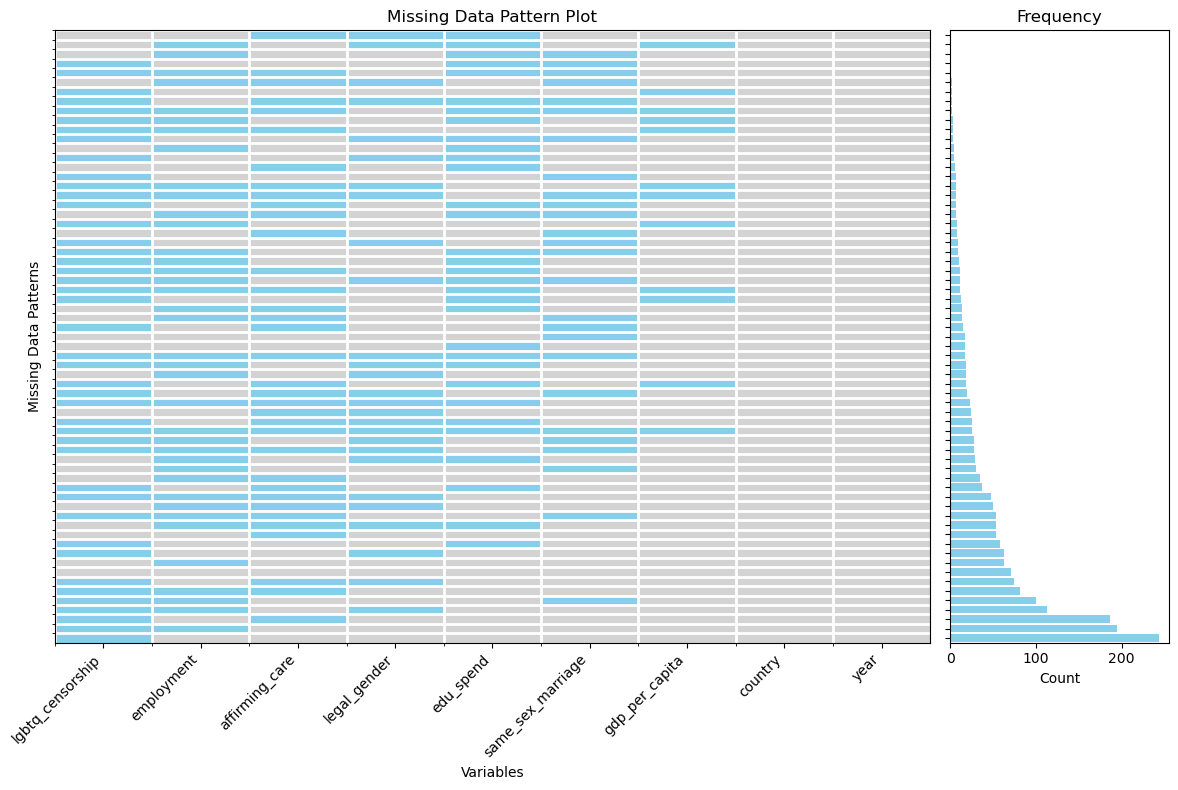

In [4]:
pattern_df = cleaned_rights.isnull().astype(int)
pattern_df = (
    pattern_df.groupby(by=pattern_df.columns.to_list())
    .size()
    .reset_index(name="count")
    .sort_values(by="count")
    .reset_index(drop=True)
)
pattern_df = pattern_df[
    [
        "lgbtq_censorship",
        "employment",
        "affirming_care",
        "legal_gender",
        "edu_spend",
        "same_sex_marriage",
        "gdp_per_capita",
        "country",
        "year",
        "count",
    ]
]
pattern_df_no_count = pattern_df.drop(columns=["count"])

# Create plot
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [4, 1]}
)

# Prepare data for heatmap
pattern_matrix = pattern_df_no_count.astype(bool).to_numpy()

# Custom colormap
colors = ["lightgrey", "skyblue"]
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Main heatmap
im = ax1.imshow(pattern_matrix, cmap=cmap, aspect="auto", interpolation="nearest")

# Set labels
ax1.set_xlabel("Variables")
ax1.set_ylabel("Missing Data Patterns")
ax1.set_title("Missing Data Pattern Plot")

# Set x-axis labels (variable names)
ax1.set_xticks(range(len(pattern_df_no_count.columns)))
ax1.set_xticklabels(pattern_df_no_count.columns, rotation=45, ha="right")

# Set y-axis labels (none)
ax1.set_yticks([])
ax1.set_yticklabels([])

# Add grid
ax1.set_xticks(np.arange(len(pattern_df_no_count.columns)) - 0.5, minor=True)
ax1.set_yticks(np.arange(len(pattern_df_no_count.index)) - 0.5, minor=True)
ax1.grid(which="minor", color="white", linewidth=2)

# Frequency bar chart - match the spacing of the left plot
counts = pattern_df["count"]
y_positions = np.arange(len(pattern_df_no_count.index))

# Create bars with same height as the heatmap rows
bar_height = 0.8  # Adjust this to match heatmap cell height
bars = ax2.barh(y_positions, counts, height=bar_height, color="skyblue", align="center")

ax2.set_xlabel("Count")
ax2.set_ylabel("")
ax2.set_yticks(y_positions)
ax2.set_yticklabels([])
ax2.set_title("Frequency")

# Set same y-limits as the main plot to ensure alignment
ax2.set_ylim(ax1.get_ylim())

plt.tight_layout()
plt.show()


## 3. Spinogram and Spineplot

In [5]:
# change R comment (not legal gender categories but same sex marriage)

spino_data = cleaned_rights.copy()
spino_data["gdp_missing"] = spino_data["gdp_per_capita"].isnull()

alt.Chart(spino_data).mark_bar().encode(
    x=alt.X("same_sex_marriage:N").title("Same Sex Marriage").axis(alt.Axis(labelAngle=-45)),
    y=alt.Y("count()", stack="normalize", title="Percent of Missingness"),
    color=alt.Color("gdp_missing:N",
                    scale=alt.Scale(domain=[True, False],
                                    range=["skyblue", "lightgrey"]),
                   legend=None),
    tooltip=["same_sex_marriage", "gdp_missing", "count()"]
).properties(
    width=300,
    height=300,
    title="Missingness of GDP per Capita by Same-Sex Marriage"
)

alt.Chart(...)

In [6]:
# change R comment (not legal gender categories but same sex marriage)
spino_data["edu_missing"] = spino_data["edu_spend"].isnull()

alt.Chart(spino_data).mark_bar().encode(
    x=alt.X("same_sex_marriage:N").title("Same Sex Marriage").axis(alt.Axis(labelAngle=-45)),
    y=alt.Y("count()", stack="normalize", title="Percent of Missingness"),
    color=alt.Color("edu_missing:N",
                    scale=alt.Scale(domain=[True, False],
                                    range=["skyblue", "lightgrey"]),
                   legend=None),
    tooltip=["same_sex_marriage", "edu_missing", "count()"]
).properties(
    width=300,
    height=300,
    title="Missingness of Education Spending by Same-Sex Marriage"
)

alt.Chart(...)

## 4. MICE using PMM

In [36]:
# NOTE: The IterativeImputer estimator is still experimental for now: the predictions and the API might change without any deprecation cycle.

# subset the columns
impute_df = cleaned_rights[[
    "gdp_per_capita", "edu_spend", "same_sex_marriage",
    "lgbtq_censorship", "employment", "affirming_care", "legal_gender"
]].copy()

# convert categorical variables to category dtype
# and make numeric encodings for imputation
categorical_cols = [
    "same_sex_marriage", "lgbtq_censorship",
    "employment", "affirming_care", "legal_gender"
]
for col in categorical_cols:
    impute_df[col] = impute_df[col].astype("category")
    impute_df[col] = impute_df[col].cat.codes.replace(-1, np.nan)

# run multiple imputation (predictive mean matching style) to produce 5 imputed datasets
imputed_dfs = []

for random_state in range(123, 128): # set random state for each iteration for reproducibility
    imputer = IterativeImputer(random_state=random_state, sample_posterior=True)
    imputed_array = imputer.fit_transform(impute_numeric)
    imputed_df = pd.DataFrame(imputed_array, columns=impute_numeric.columns)
    imputed_dfs.append(imputed_df)

## 5. Visual Comparison for Before and After Imputation

In [40]:
pd.concat(imputed_dfs, keys=range(1, 6)).reset_index(names=['imputation_iteration', 'old_index']).drop(columns='old_index')

,imputation_iteration,gdp_per_capita,edu_spend,same_sex_marriage,lgbtq_censorship,employment,affirming_care,legal_gender
0,1,11742.600000,4.143817,0.000000,1.000000,2.437982,2.039989,4.564376
1,1,59109.020000,3.370411,-0.277333,2.337283,3.009667,5.000000,1.935714
2,1,21066.460000,4.830000,1.687440,1.194420,2.283246,2.783483,3.780547
3,1,5044.120000,2.470000,0.097647,1.440083,2.918919,4.000000,4.000000
4,1,44667.930000,5.220000,2.543123,5.000000,3.387551,2.000000,5.000000
...,...,...,...,...,...,...,...,...
10620,5,74577.510000,5.310666,3.000000,5.000000,3.000000,6.000000,5.000000
10621,5,31019.310000,5.906402,3.000000,1.598497,3.000000,2.000000,3.000000
10622,5,61548.761607,5.066838,0.000000,1.699714,4.000000,3.642261,1.000000
10623,5,13491.880000,3.535962,0.000000,2.715233,3.639221,2.000000,4.000000


In [ ]:
alt.Chart(movies).transform_density(
    'runtime',
    as_=['runtime', 'density']  # Give the name "density" the KDE columns we just created
).mark_area().encode(
    x='runtime',
    y='density:Q'
)

In [ ]:
# redo title for edu spending
# Government education spending as a percentage of GDP